# Data Preprocessing dan Ekstraksi Fitur

## Preprocessing: Penanganan Outliers dan Interpolasi

Pada tahap _Data Understanding_, kita telah mengidentifikasi adanya kemungkinan nilai _outliers_ pada deret waktu. Untuk menangani permasalahan ini dan mempersiapkan data agar bisa diekstrak fiturnya secara mulus, kita menerapkan pembersihan data menggunakan metode Rentang Interkuartil (IQR) dan mengisi (imputasi) kekosongan data menggunakan **interpolasi linier**.

Di akhir proses imputasi, teknik _backward fill_ (`bfill`) serta _forward fill_ (`ffill`) dimanfaatkan guna mengatasi nilai kosong pada bagian pinggir atau awalan dan akhiran rangkaian data yang tidak bisa diinterpolasi secara linier.

Berikut adalah tahapan deteksi outlier, imputasi, dan penyimpanan dataset untuk masing-masing polutan udara:

### 1. Karbon Monoksida (CO)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Baca data CO

df = pd.read_csv("../../data/polutan/CO_Outlier.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['CO'] = pd.to_numeric(df['CO'], errors='coerce')

# Hitung IQR
Q1 = df['CO'].quantile(0.25)
Q3 = df['CO'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['CO'] < lower_bound) | (df['CO'] > upper_bound)]

print("Jumlah Outlier CO (IQR):", len(outliers_iqr))

Jumlah Outlier CO (IQR): 1


Visualisasi batas ambang IQR terhadap distribusi data CO:

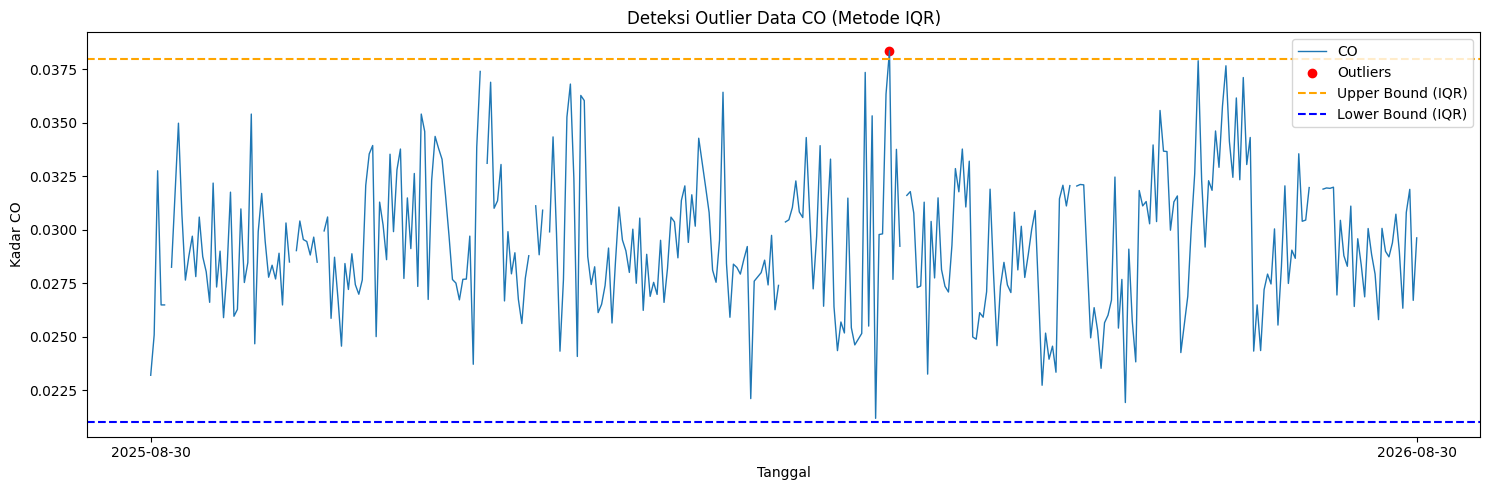

In [2]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['CO'], label="CO", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['CO'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data CO (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar CO")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan outlier dan pengisian nilai yang hilang untuk **CO**:

```python
# Tandai outlier menjadi NaN
df['CO_cleaned'] = df['CO'].mask((df['CO'] < lower_bound) | (df['CO'] > upper_bound))

# Lakukan interpolasi linier pada NaN yang sudah dibuat
df['CO_filled'] = df['CO_cleaned'].interpolate(method='linear').bfill().ffill()

# Simpan data yang telah dibersihkan dan diinterpolasi ke file CSV baru
df_co = pd.DataFrame({"date": df['date'], "CO": df['CO_filled']})
df_co.to_csv("../../data/polutan/CO_after.csv", index=False)
print("Data CO berhasil diproses dan disimpan ke CO_after.csv")
```

### 2. Sulfur Dioksida (SO2)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/polutan/SO2_Outlier.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['SO2'] = pd.to_numeric(df['SO2'], errors='coerce')

# Hitung IQR
Q1 = df['SO2'].quantile(0.25)
Q3 = df['SO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['SO2'] < lower_bound) | (df['SO2'] > upper_bound)]

print("Jumlah Outlier SO2 (IQR):", len(outliers_iqr))

Jumlah Outlier SO2 (IQR): 7


Visualisasi batas ambang IQR terhadap distribusi data SO2:

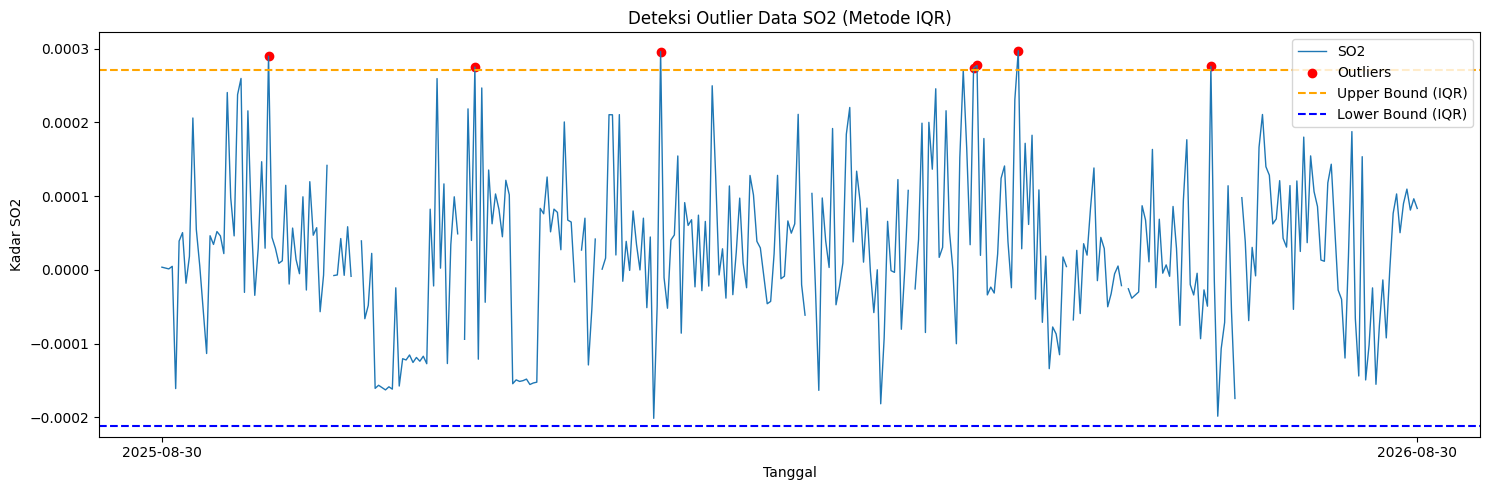

In [4]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['SO2'], label="SO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['SO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data SO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar SO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan outlier dan pengisian nilai yang hilang untuk **SO2**:

```python
# Tandai outlier menjadi NaN
df['SO2_cleaned'] = df['SO2'].mask((df['SO2'] < lower_bound) | (df['SO2'] > upper_bound))

# Lakukan interpolasi linier pada NaN yang sudah dibuat
df['SO2_filled'] = df['SO2_cleaned'].interpolate(method='linear').bfill().ffill()

# Simpan data yang telah dibersihkan dan diinterpolasi ke file CSV baru
df_so2 = pd.DataFrame({"date": df['date'], "SO2": df['SO2_filled']})
df_so2.to_csv("../../data/polutan/SO2_after.csv", index=False)
print("Data SO2 berhasil diproses dan disimpan ke SO2_after.csv")
```

### 3. Nitrogen Dioksida (NO2)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../../data/polutan/NO2_Outlier.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)
df['NO2'] = pd.to_numeric(df['NO2'], errors='coerce')

# Hitung IQR
Q1 = df['NO2'].quantile(0.25)
Q3 = df['NO2'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter outlier
outliers_iqr = df[(df['NO2'] < lower_bound) | (df['NO2'] > upper_bound)]

print("Jumlah Outlier NO2 (IQR):", len(outliers_iqr))

Jumlah Outlier NO2 (IQR): 0


Visualisasi batas ambang IQR terhadap distribusi data NO2:

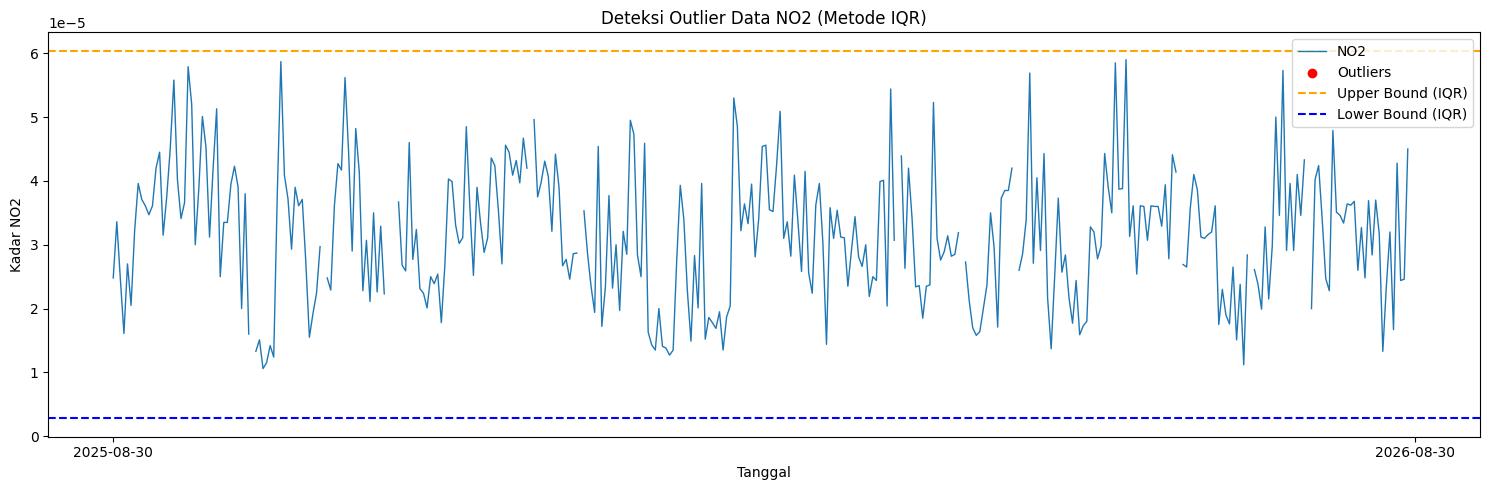

In [6]:
plt.figure(figsize=(15,5))
plt.plot(df['date'], df['NO2'], label="NO2", linewidth=1)

plt.scatter(outliers_iqr['date'], outliers_iqr['NO2'],
            color='red', marker='o', label="Outliers")

plt.axhline(upper_bound, color='orange', linestyle='dashed', label="Upper Bound (IQR)")
plt.axhline(lower_bound, color='blue',   linestyle='dashed', label="Lower Bound (IQR)")

plt.title("Deteksi Outlier Data NO2 (Metode IQR)")
plt.xlabel("Tanggal")
plt.ylabel("Kadar NO2")
plt.legend()
plt.tight_layout()
plt.xticks(
    ticks=[df['date'].iloc[0], df['date'].iloc[-1]],
    labels=[df['date'].iloc[0].strftime('%Y-%m-%d'),
            df['date'].iloc[-1].strftime('%Y-%m-%d')]
)
plt.show()

Penanganan outlier dan pengisian nilai yang hilang untuk **NO2**:

```python
# Tandai outlier menjadi NaN
df['NO2_cleaned'] = df['NO2'].mask((df['NO2'] < lower_bound) | (df['NO2'] > upper_bound))

# Lakukan interpolasi linier pada NaN yang sudah dibuat
df['NO2_filled'] = df['NO2_cleaned'].interpolate(method='linear').bfill().ffill()

# Simpan data yang telah dibersihkan dan diinterpolasi ke file CSV baru
df_no2 = pd.DataFrame({"date": df['date'], "NO2": df['NO2_filled']})
df_no2.to_csv("../../data/polutan/NO2_after.csv", index=False)
print("Data NO2 berhasil diproses dan disimpan ke NO2_after.csv")
```

### 4. Visualisasi Gabungan Setelah Preprocessing

Setelah proses penanganan *outlier* dan interpolasi selesai untuk ketiga polutan, kita dapat melihat visualisasi gabungan dari kadar CO, SO2, dan NO2 yang telah bersih dan utuh. Deret waktu ini telah siap untuk dilanjutkan ke tahap ekstraksi fitur.

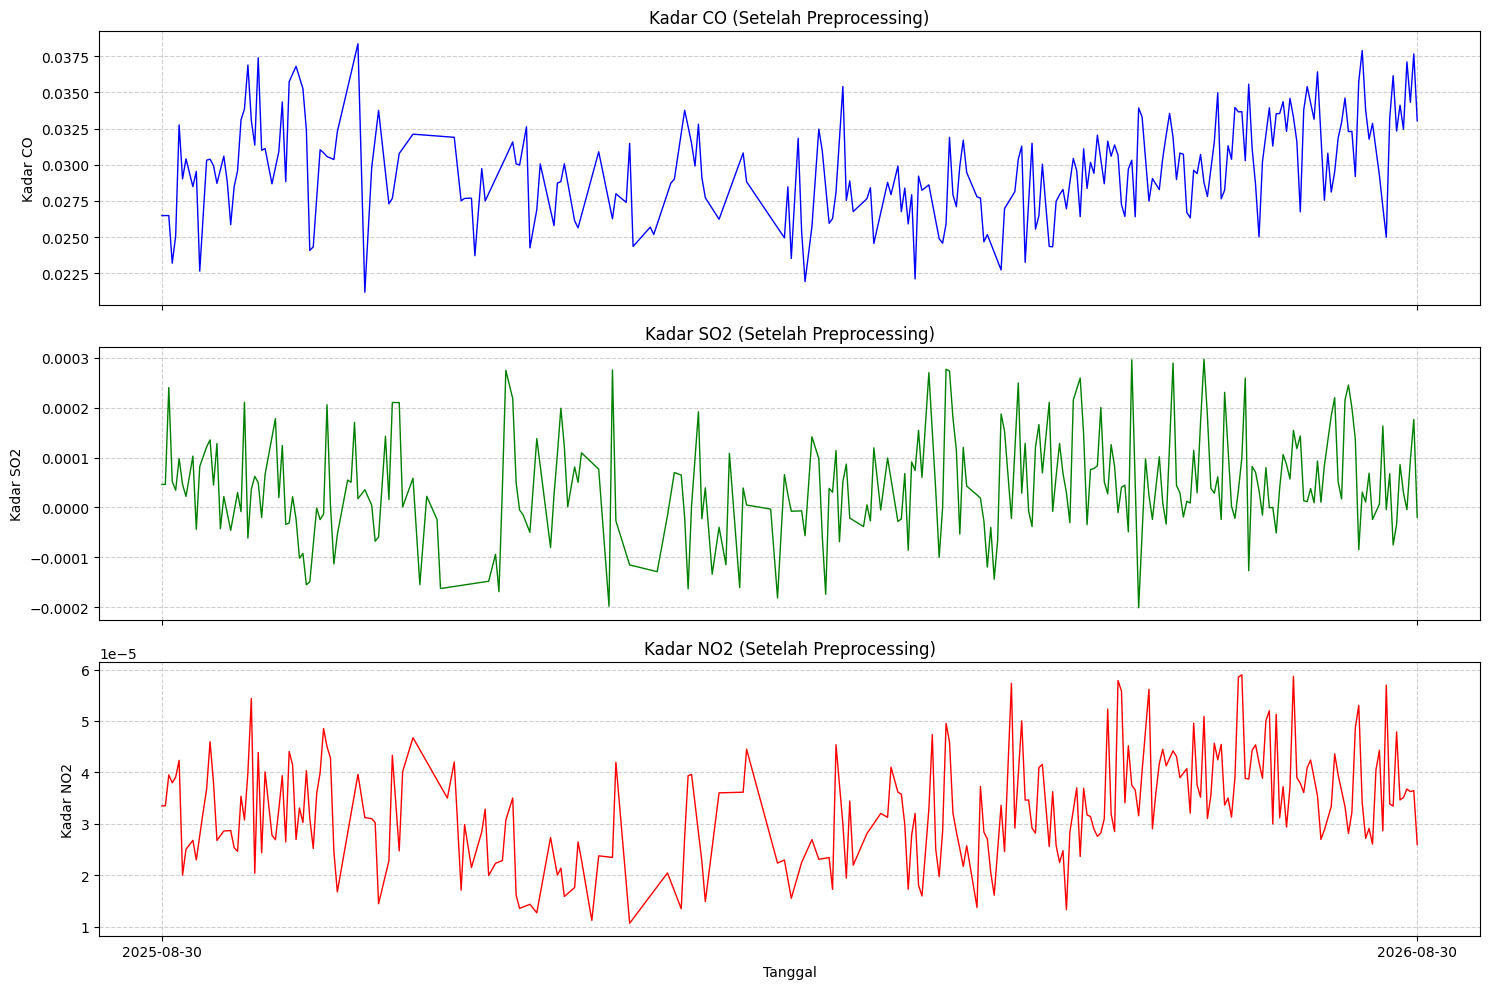

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Memuat data yang telah diproses
df_co = pd.read_csv("../../data/polutan/CO_after.csv")
df_so2 = pd.read_csv("../../data/polutan/SO2_after.csv")
df_no2 = pd.read_csv("../../data/polutan/NO2_after.csv")

df_co['date'] = pd.to_datetime(df_co['date'])
df_so2['date'] = pd.to_datetime(df_so2['date'])
df_no2['date'] = pd.to_datetime(df_no2['date'])

# Membuat subplot untuk ketiga polutan
fig, axes = plt.subplots(3, 1, figsize=(15, 10), sharex=True)

# Plot CO
axes[0].plot(df_co['date'], df_co['CO'], color='blue', linewidth=1)
axes[0].set_title('Kadar CO (Setelah Preprocessing)')
axes[0].set_ylabel('Kadar CO')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Plot SO2
axes[1].plot(df_so2['date'], df_so2['SO2'], color='green', linewidth=1)
axes[1].set_title('Kadar SO2 (Setelah Preprocessing)')
axes[1].set_ylabel('Kadar SO2')
axes[1].grid(True, linestyle='--', alpha=0.6)

# Plot NO2
axes[2].plot(df_no2['date'], df_no2['NO2'], color='red', linewidth=1)
axes[2].set_title('Kadar NO2 (Setelah Preprocessing)')
axes[2].set_xlabel('Tanggal')
axes[2].set_ylabel('Kadar NO2')
axes[2].grid(True, linestyle='--', alpha=0.6)

# Menyesuaikan tampilan sumbu X
plt.xticks(
    ticks=[df_co['date'].iloc[0], df_co['date'].iloc[-1]],
    labels=[df_co['date'].iloc[0].strftime('%Y-%m-%d'),
            df_co['date'].iloc[-1].strftime('%Y-%m-%d')]
)

plt.tight_layout()
plt.show()

Selain divisualisasikan dalam subplot terpisah, kita juga dapat menumpuk (*overlay*) ketiga polutan dalam satu grafik untuk membandingkan fluktuasinya secara langsung. Karena skala kadar polutan mungkin berbeda, perbandingan ini difokuskan pada pengamatan pola tren perubahannya.

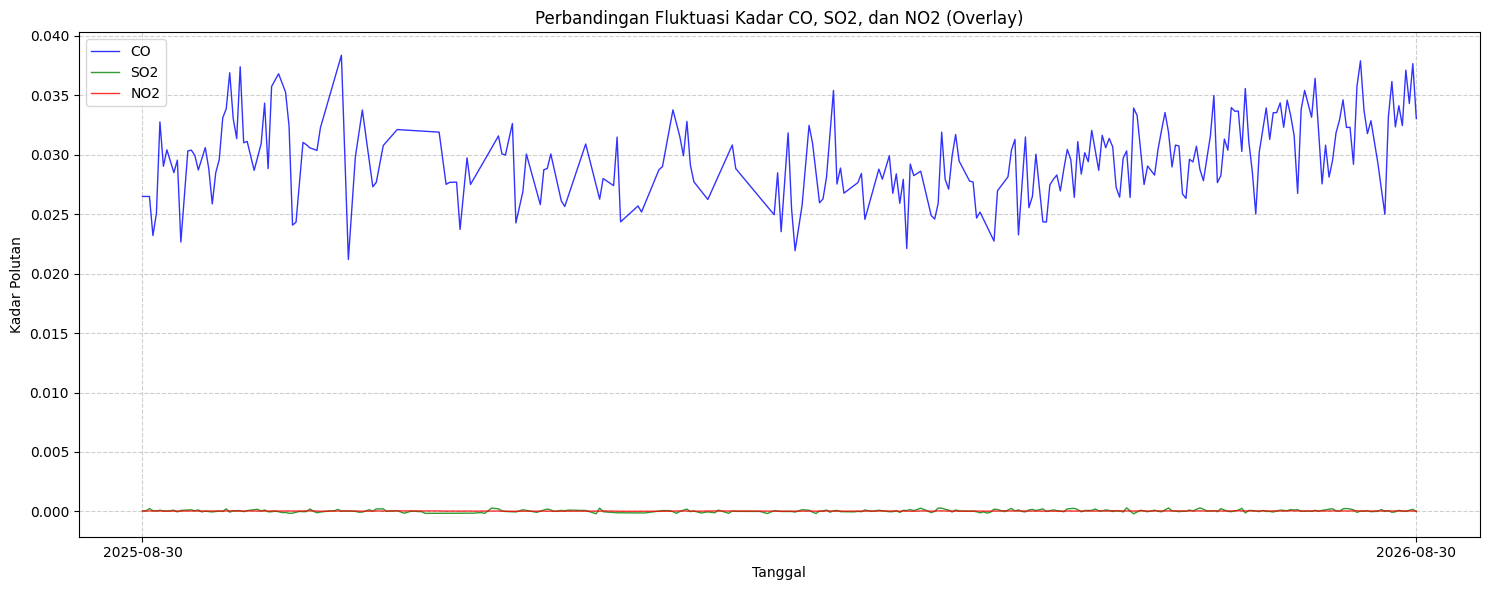

In [8]:
plt.figure(figsize=(15, 6))

# Plot ketiga polutan dalam satu axis
plt.plot(df_co['date'], df_co['CO'], color='blue', label='CO', linewidth=1, alpha=0.8)
plt.plot(df_so2['date'], df_so2['SO2'], color='green', label='SO2', linewidth=1, alpha=0.8)
plt.plot(df_no2['date'], df_no2['NO2'], color='red', label='NO2', linewidth=1, alpha=0.8)

plt.title('Perbandingan Fluktuasi Kadar CO, SO2, dan NO2 (Overlay)')
plt.xlabel('Tanggal')
plt.ylabel('Kadar Polutan')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Menyesuaikan tampilan sumbu X
plt.xticks(
    ticks=[df_co['date'].iloc[0], df_co['date'].iloc[-1]],
    labels=[df_co['date'].iloc[0].strftime('%Y-%m-%d'),
            df_co['date'].iloc[-1].strftime('%Y-%m-%d')]
)

plt.tight_layout()
plt.show()

## Ekstraksi Fitur Deret Waktu (Time Series)

Dengan data deret waktu polutan udara yang konsisten (tanpa tanggal hilang dan tanpa _outlier_), kita dapat melangkah ke ekstraksi berbagai fitur statistik, temporal, maupun spektral. Fitur-fitur ini sangat berguna sebagai parameter *input* yang merepresentasikan karakteristik *trend* harian polutan ke dalam model _machine learning_ maupun _deep learning_.

Kita akan memanfaatkan modul pustaka Python bernama `tsfel` (_Time Series Feature Extraction Library_) guna mempermudah proses komputasi serta standarisasi ragam tipe fitur. Untuk memastikan hasil ekstraksi mudah dibaca, format akhir data CSV akan di-*transpose* sehingga struktur tabel menjadi format dua kolom, yakni *Feature* dan *Value*.

### 1. Karbon Monoksida (CO)

```python
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

# ---------- 1. Muat data yang sudah dibersihkan ----------
df = pd.read_csv('../../data/polutan/CO_after.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'CO'
fs = 1
signal_1d = df[target_pollutant].astype(float).values

# ---------- 2. Inisiasi Daftar Fitur TSFEL ----------
FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

# ---------- 3. Fungsi ekstraksi dan penyeragaman output ----------
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

# Lakukan ekstraksi iteratif pada fitur
row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])
# Export hasil ke file CSV
extracted_features_final.to_csv(f'../../data/polutan/{target_pollutant}_widang_TSFEL.csv', index=False)
print(f"Berhasil mengekstrak {len(FEATURE_LIST)} fitur untuk {target_pollutant}.")
```

Contoh cuplikan hasil ekstraksi fitur **CO**:

In [9]:
df_feat = pd.read_csv("../../data/polutan/CO_widang_TSFEL.csv")
df_feat.head(10)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.320845,10.74496,3.0,0.000879,184.819043,0.037897,0.029439,0.029169,0.02119,0.003156,...,0.129537,0.47419,0.000013,0.698436,0.001767,0.007519,2.147071,0.00728,0.00006,0.0


### 2. Sulfur Dioksida (SO2)

```python
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

df = pd.read_csv('../../data/polutan/SO2_after.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'SO2'
fs = 1
signal_1d = df[target_pollutant].astype(float).values

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

# Fungsi bantu untuk merapikan output TSFEL
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])
extracted_features_final.to_csv(f'../../data/polutan/{target_pollutant}_widang_TSFEL.csv', index=False)
print(f"Berhasil mengekstrak fitur untuk {target_pollutant}.")
```

Contoh cuplikan hasil ekstraksi fitur **SO2**:

In [10]:
df_feat = pd.read_csv("../../data/polutan/SO2_widang_TSFEL.csv")
df_feat.head(10)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,0.000004,0.026307,2.0,1.053692e-08,186.794715,0.000274,0.000026,0.000025,-0.000201,0.000099,...,0.147246,0.172626,1.702950e-08,0.025822,0.000003,0.000142,2.153694,0.000142,2.183313e-08,107.0


### 3. Nitrogen Dioksida (NO2)

```python
import pandas as pd
import numpy as np
import inspect
import tsfel.feature_extraction.features as tsfel_features

df = pd.read_csv('../../data/polutan/NO2_after.csv')
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

target_pollutant = 'NO2'
fs = 1
signal_1d = df[target_pollutant].astype(float).values

FEATURE_LIST = """abs_energy auc autocorr average_power calc_centroid calc_max calc_mean
calc_median calc_min calc_std calc_var dfa distance ecdf ecdf_percentile ecdf_percentile_count
ecdf_slope entropy fundamental_frequency higuchi_fractal_dimension hist_mode human_range_energy
hurst_exponent interq_range kurtosis lempel_ziv lpcc max_frequency max_power_spectrum
maximum_fractal_length mean_abs_deviation mean_abs_diff mean_diff median_abs_deviation
median_abs_diff median_diff median_frequency mfcc mse negative_turning neighbourhood_peaks
petrosian_fractal_dimension pk_pk_distance positive_turning power_bandwidth rms skewness slope
spectral_centroid spectral_decrease spectral_distance spectral_entropy spectral_kurtosis
spectral_positive_turning spectral_roll_off spectral_roll_on spectral_skewness spectral_slope
spectral_spread spectral_variation spectrogram_mean_coeff sum_abs_diff wavelet_abs_mean
wavelet_energy wavelet_entropy wavelet_std wavelet_var zero_cross""".split()

# Fungsi bantu untuk merapikan output TSFEL
def to_scalar(result):
    if isinstance(result, dict) and "values" in result:
        result = result["values"]
    if isinstance(result, (list, tuple, np.ndarray)):
        arr = np.asarray(result, dtype=float)
        return float(np.nanmean(arr))
    return float(result)


def extract_one(fn_name, signal, fs):
    fn = getattr(tsfel_features, fn_name)
    params = inspect.signature(fn).parameters
    if "fs" in params:
        result = fn(signal, fs)
    else:
        result = fn(signal)
    return to_scalar(result)

row = {}
for fn_name in FEATURE_LIST:
    row[fn_name] = extract_one(fn_name, signal_1d, fs)

extracted_features_final = pd.DataFrame([row])
extracted_features_final.to_csv(f'../../data/polutan/{target_pollutant}_widang_TSFEL.csv', index=False)
print(f"Berhasil mengekstrak fitur untuk {target_pollutant}.")
```

Contoh cuplikan hasil ekstraksi fitur **NO2**:

In [11]:
df_feat = pd.read_csv("../../data/polutan/NO2_widang_TSFEL.csv")
df_feat.head(10)

,abs_energy,auc,autocorr,average_power,calc_centroid,calc_max,calc_mean,calc_median,calc_min,calc_std,...,spectral_spread,spectral_variation,spectrogram_mean_coeff,sum_abs_diff,wavelet_abs_mean,wavelet_energy,wavelet_entropy,wavelet_std,wavelet_var,zero_cross
0,3.989307e-07,0.011463,4.0,1.092961e-09,200.948783,0.000059,0.000031,0.000031,0.000011,0.00001,...,0.151381,0.372225,1.464627e-10,0.002252,0.000002,0.000015,2.152183,0.000015,2.282557e-10,0.0


## Penjelasan Domain TSFEL

Pustaka TSFEL membagi 68 fitur deret waktu menjadi tiga domain utama: **Statistik (Statistical)**, **Waktu (Temporal)**, dan **Frekuensi (Spectral)**. Berikut adalah penjabaran lengkap untuk masing-masing fitur beserta rumusnya, serta hasil perhitungannya yang diterapkan pada polutan NO2 (dari `NO2_after.csv`) yang disajikan pada hasil akhir (`NO2_widang_TSFEL.csv`).

### 1. Domain Statistical
Domain statistik mengekstrak metrik kuantitatif dan karakteristik sebaran serta bentuk distribusi dari sinyal deret waktu. Domain ini terdiri dari 17 fitur utama yang fokus pada distribusi.

1. **`calc_max`**
   - **Penjelasan**: Nilai maksimum dari deret waktu.
   - **Rumus**: $\max(x)$
   - **Hasil (NO2)**: `5.51000e-05`

2. **`calc_min`**
   - **Penjelasan**: Nilai minimum dari deret waktu.
   - **Rumus**: $\min(x)$
   - **Hasil (NO2)**: `5.12000e-06`

3. **`calc_mean`**
   - **Penjelasan**: Rata-rata (mean) dari deret waktu.
   - **Rumus**: $\mu = \frac{1}{N} \sum_{i=1}^N x_i$
   - **Hasil (NO2)**: `2.84004e-05`

4. **`calc_median`**
   - **Penjelasan**: Nilai tengah (median) dari deret waktu.
   - **Rumus**: $\text{median}(x)$
   - **Hasil (NO2)**: `2.81250e-05`

5. **`calc_std`**
   - **Penjelasan**: Standar deviasi, mengukur tingkat penyebaran data.
   - **Rumus**: $\sigma = \sqrt{\frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2}$
   - **Hasil (NO2)**: `1.01280e-05`

6. **`calc_var`**
   - **Penjelasan**: Varians, kuadrat dari standar deviasi.
   - **Rumus**: $\sigma^2 = \frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2$
   - **Hasil (NO2)**: `1.02577e-10`

7. **`ecdf`**
   - **Penjelasan**: Fungsi distribusi kumulatif empiris.
   - **Rumus**: $\hat{F}(t) = \frac{1}{N} \sum_{i=1}^N \mathbf{1}_{x_i \le t}$
   - **Hasil (NO2)**: `1.50273e-02`

8. **`ecdf_percentile`**
   - **Penjelasan**: Nilai ECDF pada persentil tertentu.
   - **Rumus**: $P_{perc}(\hat{F})$
   - **Hasil (NO2)**: `2.84000e-05`

9. **`ecdf_percentile_count`**
   - **Penjelasan**: Jumlah data yang berada di bawah persentil ECDF.
   - **Rumus**: $\sum \mathbf{1}_{x_i \le P_{perc}}$
   - **Hasil (NO2)**: `1.82500e+02`

10. **`ecdf_slope`**
   - **Penjelasan**: Kemiringan dari kurva ECDF.
   - **Rumus**: $\frac{\Delta y}{\Delta x} \text{ pada } \hat{F}(t)$
   - **Hasil (NO2)**: `3.47222e+04`

11. **`hist_mode`**
   - **Penjelasan**: Modus (nilai paling sering muncul) berdasarkan histogram.
   - **Rumus**: $\arg\max_j (\text{count}(bin_j))$
   - **Hasil (NO2)**: `2.76110e-05`

12. **`interq_range`**
   - **Penjelasan**: Jangkauan interkuartil (IQR), selisih Q3 dan Q1.
   - **Rumus**: $IQR = Q_3 - Q_1$
   - **Hasil (NO2)**: `1.45000e-05`

13. **`kurtosis`**
   - **Penjelasan**: Keruncingan (peakedness) dari distribusi data.
   - **Rumus**: $K = \frac{\frac{1}{N} \sum_{i=1}^N (x_i - \mu)^4}{\sigma^4} - 3$
   - **Hasil (NO2)**: `-4.15397e-01`

14. **`skewness`**
   - **Penjelasan**: Kemiringan (asimetri) dari distribusi data.
   - **Rumus**: $S = \frac{\frac{1}{N} \sum_{i=1}^N (x_i - \mu)^3}{\sigma^3}$
   - **Hasil (NO2)**: `1.02776e-01`

15. **`mean_abs_deviation`**
   - **Penjelasan**: Rata-rata simpangan absolut dari mean.
   - **Rumus**: $MAD = \frac{1}{N} \sum_{i=1}^N |x_i - \mu|$
   - **Hasil (NO2)**: `8.22498e-06`

16. **`median_abs_deviation`**
   - **Penjelasan**: Median dari simpangan absolut dari median.
   - **Rumus**: $\text{Median}(|x_i - \text{median}(x)|)$
   - **Hasil (NO2)**: `7.10833e-06`

17. **`rms`**
   - **Penjelasan**: Root Mean Square (energi kuadrat rata-rata).
   - **Rumus**: $RMS = \sqrt{\frac{1}{N} \sum_{i=1}^N x_i^2}$
   - **Hasil (NO2)**: `3.01523e-05`

### 2. Domain Temporal
Domain temporal mengevaluasi sinyal dari segi urutan waktunya. Terdiri dari 25 fitur yang mengukur dependensi, jarak, autokorelasi, dan kompleksitas waktu.

1. **`abs_energy`**
   - **Penjelasan**: Total energi absolut dari deret waktu.
   - **Rumus**: $E = \sum_{i=1}^N x_i^2$
   - **Hasil (NO2)**: `3.32752e-07`

2. **`auc`**
   - **Penjelasan**: Area di bawah kurva sinyal (Area Under Curve).
   - **Rumus**: $AUC = \sum_{i=1}^{N-1} \frac{x_i + x_{i+1}}{2}$
   - **Hasil (NO2)**: `1.03695e-02`

3. **`autocorr`**
   - **Penjelasan**: Autokorelasi sinyal, kesamaan sinyal dengan versi tertundanya.
   - **Rumus**: $R(\tau) = \sum_{i=1}^{N-\tau} x_i x_{i+\tau}$
   - **Hasil (NO2)**: `1.70000e+01`

4. **`average_power`**
   - **Penjelasan**: Daya rata-rata dari sinyal waktu.
   - **Rumus**: $P = \frac{1}{N} \sum_{i=1}^N x_i^2$
   - **Hasil (NO2)**: `9.11650e-10`

5. **`calc_centroid`**
   - **Penjelasan**: Titik pusat dari urutan waktu (Time Centroid).
   - **Rumus**: $C_t = \frac{\sum t_i \cdot x_i}{\sum x_i}$
   - **Hasil (NO2)**: `2.03671e+02`

6. **`dfa`**
   - **Penjelasan**: Detrended Fluctuation Analysis, untuk mengukur dependensi fraktal.
   - **Rumus**: $F(n) \propto n^\alpha$
   - **Hasil (NO2)**: `1.01119e+00`

7. **`distance`**
   - **Penjelasan**: Total jarak (panjang lintasan) antar titik-titik berturutan.
   - **Rumus**: $D = \sum_{i=1}^{N-1} \sqrt{1 + (x_{i+1} - x_i)^2}$
   - **Hasil (NO2)**: `3.65000e+02`

8. **`entropy`**
   - **Penjelasan**: Shannon Entropy, mengukur ketidakpastian sinyal.
   - **Rumus**: $H = -\sum p(x) \log p(x)$
   - **Hasil (NO2)**: `9.27850e-01`

9. **`higuchi_fractal_dimension`**
   - **Penjelasan**: Dimensi Fraktal Higuchi, mengukur kompleksitas bentuk.
   - **Rumus**: $L(k) \propto k^{-D}$
   - **Hasil (NO2)**: `1.84022e+00`

10. **`hurst_exponent`**
   - **Penjelasan**: Eksponen Hurst, indikasi memori jangka panjang waktu.
   - **Rumus**: $E[\frac{R(n)}{S(n)}] = C n^H$
   - **Hasil (NO2)**: `8.03093e-01`

11. **`lempel_ziv`**
   - **Penjelasan**: Kompleksitas Lempel-Ziv, mengukur tingkat kompresibilitas sinyal.
   - **Rumus**: $LZ = \frac{c(N)}{\frac{N}{\log N}}$
   - **Hasil (NO2)**: `1.72131e-01`

12. **`maximum_fractal_length`**
   - **Penjelasan**: Panjang maksimal fraktal di berbagai skala pengukuran.
   - **Rumus**: $L_{max} = \max_k (L(k))$
   - **Hasil (NO2)**: `-2.69521e+00`

13. **`mean_abs_diff`**
   - **Penjelasan**: Rata-rata dari perbedaan absolut titik berurutan.
   - **Rumus**: $\mu_{\Delta} = \frac{1}{N-1} \sum_{i=1}^{N-1} |x_{i+1} - x_i|$
   - **Hasil (NO2)**: `4.56367e-06`

14. **`mean_diff`**
   - **Penjelasan**: Rata-rata perbedaan antara titik berurutan.
   - **Rumus**: $\mu_{d} = \frac{1}{N-1} \sum_{i=1}^{N-1} (x_{i+1} - x_i)$
   - **Hasil (NO2)**: `1.20548e-08`

15. **`median_abs_diff`**
   - **Penjelasan**: Median perbedaan absolut berurutan.
   - **Rumus**: $\text{Median}(|x_{i+1} - x_i|)$
   - **Hasil (NO2)**: `2.50000e-06`

16. **`median_diff`**
   - **Penjelasan**: Median dari selisih titik berurutan.
   - **Rumus**: $\text{Median}(x_{i+1} - x_i)$
   - **Hasil (NO2)**: `4.00000e-07`

17. **`mse`**
   - **Penjelasan**: Mean Squared Error dari sinyal terhadap rata-ratanya.
   - **Rumus**: $MSE = \frac{1}{N} \sum_{i=1}^N (x_i - \mu)^2$
   - **Hasil (NO2)**: `1.28358e+00`

18. **`negative_turning`**
   - **Penjelasan**: Jumlah titik belok bergradien negatif (puncak yang turun).
   - **Rumus**: $\sum \mathbf{1}_{x_{i-1} < x_i > x_{i+1}}$
   - **Hasil (NO2)**: `6.70000e+01`

19. **`neighbourhood_peaks`**
   - **Penjelasan**: Jumlah puncak pada area bertetangga yang ditentukan.
   - **Rumus**: $\sum \text{Peaks}(x, \text{window})$
   - **Hasil (NO2)**: `1.60000e+01`

20. **`petrosian_fractal_dimension`**
   - **Penjelasan**: Dimensi Fraktal Petrosian.
   - **Rumus**: $D = \frac{\log_{10}(N)}{\log_{10}(N) + \log_{10}(\frac{N}{N + 0.4 N_{\Delta}})}$
   - **Hasil (NO2)**: `1.02404e+00`

21. **`pk_pk_distance`**
   - **Penjelasan**: Jarak dari puncak tertinggi ke lembah terendah (Peak-to-Peak).
   - **Rumus**: $P2P = \max(x) - \min(x)$
   - **Hasil (NO2)**: `4.99800e-05`

22. **`positive_turning`**
   - **Penjelasan**: Jumlah titik belok bergradien positif (lembah yang naik).
   - **Rumus**: $\sum \mathbf{1}_{x_{i-1} > x_i < x_{i+1}}$
   - **Hasil (NO2)**: `6.80000e+01`

23. **`slope`**
   - **Penjelasan**: Kemiringan tren regresi linier secara keseluruhan.
   - **Rumus**: $m = \frac{\sum (t_i - \bar{t})(x_i - \mu)}{\sum (t_i - \bar{t})^2}$
   - **Hasil (NO2)**: `2.85331e-08`

24. **`sum_abs_diff`**
   - **Penjelasan**: Total akumulasi perbedaan absolut titik berurutan.
   - **Rumus**: $SAD = \sum_{i=1}^{N-1} |x_{i+1} - x_i|$
   - **Hasil (NO2)**: `1.66574e-03`

25. **`zero_cross`**
   - **Penjelasan**: Jumlah titik perpotongan nol (zero-crossing).
   - **Rumus**: $\sum \mathbf{1}_{x_i \cdot x_{i+1} < 0}$
   - **Hasil (NO2)**: `0.00000e+00`

### 3. Domain Spectral
Domain spektral mentransformasi data ke domain frekuensi (melalui Fourier/Wavelet). Terdiri dari 26 fitur untuk mengukur sifat periodik, energi spektrum, dan rentang frekuensi.

1. **`fundamental_frequency`**
   - **Penjelasan**: Frekuensi dasar yang paling kuat pada spektrum.
   - **Rumus**: $f_0 = \arg\max_f (|X(f)|^2)$
   - **Hasil (NO2)**: `2.73224e-03`

2. **`max_frequency`**
   - **Penjelasan**: Frekuensi tertinggi pada analisis spektrum daya.
   - **Rumus**: $f_{max} = \max(f)$
   - **Hasil (NO2)**: `4.34426e-01`

3. **`median_frequency`**
   - **Penjelasan**: Frekuensi yang membagi spektrum daya (energi) menjadi dua bagian sama.
   - **Rumus**: $\int_0^{f_{med}} |X(f)|^2 df = \frac{1}{2} \int_0^\infty |X(f)|^2 df$
   - **Hasil (NO2)**: `4.09836e-02`

4. **`human_range_energy`**
   - **Penjelasan**: Energi sinyal pada jangkauan pendengaran manusia.
   - **Rumus**: $E_h = \sum_{f \in H} |X(f)|^2$
   - **Hasil (NO2)**: `0.00000e+00`

5. **`lpcc`**
   - **Penjelasan**: Koefisien Linear Prediction Cepstral (LPCC).
   - **Rumus**: $C_n = -a_n - \sum_{k=1}^{n-1} \frac{k}{n} C_k a_{n-k}$
   - **Hasil (NO2)**: `7.48200e-01`

6. **`mfcc`**
   - **Penjelasan**: Koefisien Mel-Frequency Cepstral (MFCC).
   - **Rumus**: $c_n = \sum_{k=1}^K (\log S_k) \cos\left[n(k-\frac{1}{2})\frac{\pi}{K}\right]$
   - **Hasil (NO2)**: `2.43670e+01`

7. **`max_power_spectrum`**
   - **Penjelasan**: Daya tertinggi dari seluruh rentang spektrum frekuensi.
   - **Rumus**: $\max_f (|X(f)|^2)$
   - **Hasil (NO2)**: `1.22004e+02`

8. **`power_bandwidth`**
   - **Penjelasan**: Lebar pita tempat akumulasi mayoritas kekuatan sinyal (daya).
   - **Rumus**: $BW = f_{upper} - f_{lower}$
   - **Hasil (NO2)**: `3.22404e-01`

9. **`spectral_centroid`**
   - **Penjelasan**: Pusat massa spektral (frekuensi rata-rata berbobot energi).
   - **Rumus**: $C_s = \frac{\sum f_k |X(f_k)|}{\sum |X(f_k)|}$
   - **Hasil (NO2)**: `1.20096e-01`

10. **`spectral_decrease`**
   - **Penjelasan**: Tingkat penurunan kekuatan spektral pada frekuensi yang meninggi.
   - **Rumus**: $D_s = \frac{\sum_{k=2}^K \frac{|X(f_k)| - |X(f_1)|}{k-1}}{\sum_{k=2}^K |X(f_k)|}$
   - **Hasil (NO2)**: `-2.52716e+00`

11. **`spectral_distance`**
   - **Penjelasan**: Jarak spektral, selisih antar kurva densitas spektrum.
   - **Rumus**: $D(X, Y) = \sqrt{\sum (X(f) - Y(f))^2}$
   - **Hasil (NO2)**: `-1.58982e+00`

12. **`spectral_entropy`**
   - **Penjelasan**: Entropi spektral, seberapa menyebar distribusi energi spektrum.
   - **Rumus**: $H_s = -\sum p_f \log p_f$
   - **Hasil (NO2)**: `6.21878e-01`

13. **`spectral_kurtosis`**
   - **Penjelasan**: Kurtosis dari kepadatan daya spektrum.
   - **Rumus**: $K_s = \frac{\sum (f - C_s)^4 |X(f)|^2}{(\sum (f - C_s)^2 |X(f)|^2)^2}$
   - **Hasil (NO2)**: `2.71723e+00`

14. **`spectral_positive_turning`**
   - **Penjelasan**: Titik belok positif pada kurva spektrum.
   - **Rumus**: $\sum \mathbf{1}_{|X(f_{i-1})| > |X(f_i)| < |X(f_{i+1})|}$
   - **Hasil (NO2)**: `6.10000e+01`

15. **`spectral_roll_off`**
   - **Penjelasan**: Frekuensi roll-off di mana sebagian besar energi spektral terkonsentrasi.
   - **Rumus**: $f_c \text{ dimana } \sum_{f=0}^{f_c} |X(f)|^2 = 0.95 \sum_{f} |X(f)|^2$
   - **Hasil (NO2)**: `4.34426e-01`

16. **`spectral_roll_on`**
   - **Penjelasan**: Frekuensi roll-on tempat sebagian kecil energi (misal 5%) terakumulasi.
   - **Rumus**: $f_c \text{ dimana } \sum_{f=0}^{f_c} |X(f)|^2 = 0.05 \sum_{f} |X(f)|^2$
   - **Hasil (NO2)**: `0.00000e+00`

17. **`spectral_skewness`**
   - **Penjelasan**: Skewness (kemiringan) dari kepadatan daya spektrum.
   - **Rumus**: $S_s = \frac{\sum (f - C_s)^3 |X(f)|^2}{(\sum (f - C_s)^2 |X(f)|^2)^{3/2}}$
   - **Hasil (NO2)**: `1.05467e+00`

18. **`spectral_slope`**
   - **Penjelasan**: Kemiringan dari spektrum daya yang dihitung menggunakan regresi linier.
   - **Rumus**: $m_s = \frac{\sum (f_i - \bar{f})(|X(f_i)| - \overline{|X(f)|})}{\sum (f_i - \bar{f})^2}$
   - **Hasil (NO2)**: `-3.35216e-02`

19. **`spectral_spread`**
   - **Penjelasan**: Sebaran spektrum atau varians frekuensi di sekeliling pusat massa.
   - **Rumus**: $V_s = \sqrt{\frac{\sum (f_k - C_s)^2 |X(f_k)|}{\sum |X(f_k)|}}$
   - **Hasil (NO2)**: `1.50384e-01`

20. **`spectral_variation`**
   - **Penjelasan**: Variasi atau jarak perubahan spektrum pada titik yang berdekatan.
   - **Rumus**: $V = 1 - \frac{\sum X_{t-1}(f) X_t(f)}{\sqrt{\sum X_{t-1}^2 \sum X_t^2}}$
   - **Hasil (NO2)**: `2.64122e-01`

21. **`spectrogram_mean_coeff`**
   - **Penjelasan**: Koefisien magnitudo rata-rata dari matriks spektrogram.
   - **Rumus**: $\frac{1}{T F} \sum_t \sum_f |S(t, f)|$
   - **Hasil (NO2)**: `1.21204e-10`

22. **`wavelet_abs_mean`**
   - **Penjelasan**: Rata-rata magnitudo absolut dari koefisien transformasi wavelet.
   - **Rumus**: $\mu_w = \frac{1}{N} \sum |W(a,b)|$
   - **Hasil (NO2)**: `1.83560e-06`

23. **`wavelet_energy`**
   - **Penjelasan**: Energi total yang terkandung di dalam koefisien wavelet.
   - **Rumus**: $E_w = \sum |W(a,b)|^2$
   - **Hasil (NO2)**: `1.42750e-05`

24. **`wavelet_entropy`**
   - **Penjelasan**: Entropi wavelet, ukuran distribusi sebaran energi di ruang waktu-frekuensi.
   - **Rumus**: $H_w = -\sum p_j \log p_j, p_j = \frac{E_j}{E_{tot}}$
   - **Hasil (NO2)**: `2.12394e+00`

25. **`wavelet_std`**
   - **Penjelasan**: Standar deviasi dari sebaran koefisien wavelet.
   - **Rumus**: $\sigma_w = \sqrt{\frac{1}{N} \sum (|W(a,b)| - \mu_w)^2}$
   - **Hasil (NO2)**: `1.41400e-05`

26. **`wavelet_var`**
   - **Penjelasan**: Varians dari koefisien dispersi wavelet.
   - **Rumus**: $\sigma_w^2$
   - **Hasil (NO2)**: `2.24529e-10`

---

## Kesimpulan
Proses preprocessing pada data polutan meliputi:

1. deteksi outlier menggunakan IQR
2. perubahan outlier menjadi nilai kosong
3. interpolasi linier untuk mengisi missing value
4. penyimpanan hasil ke `CO_after.csv`, `SO2_after.csv`, dan `NO2_after.csv`
5. ekstraksi fitur dengan TSFEL untuk menghasilkan `*_widang_TSFEL.csv`

Hasil akhir dari proses ini adalah data yang lebih bersih, lebih stabil, dan siap untuk tahap analisis lanjutan.